In [1]:
import os
import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Define SARIMA model
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        print([order, aic])
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [3]:
# Forecasting 
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len
    
    
    if method == 'last_season':
        pred_last_season = []
        
        
        for i in range(train_len, total_len, window):
            last_season = df_total[i-window:i]
            pred_last_season.extend(last_season[0])
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(df_total[:i], order=(SARIMA_result_df.iloc[0][0][0], d, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], D, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [5]:
# read in the merged station datasets
#Read In Data
path = "../../datasets/Merged-Cleaned-Simulated-Data/"
dfs = {}
for index in range(0, 6):
    filename=path+'Station' + str(index + 1) + '-Simulated-cleaned-merged-data.csv'
    print(filename)
    df = pd.read_csv(filename, sep=",", parse_dates=["Date"], index_col="Date")
    dfs['Station' + str(index + 1)] = df


../../datasets/Merged-Cleaned-Simulated-Data/Station1-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station2-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station3-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station4-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station5-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station6-Simulated-cleaned-merged-data.csv


In [5]:
# #drop flag feature and null values

# for station, df in dfs.items() :
#   # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
#   #df = df.drop('Flag', axis = 1)
#   # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
#   df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
#   df_new.dropna(inplace=True)
#   dfs[station] = df_new

In [6]:
# Vectorize wind
for station, df in dfs.items():
  wv = df.pop('Windspeed')
  wd_rad = df.pop('Winddirection')*np.pi / 180
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [7]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)
  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
  dfs[station] = df

In [8]:
#add geographical position data

position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [9]:
for station, df in dfs.items():
  lat = df.pop('Latitude')
  lon = df.pop('Longitude')
  df["x_cord"] = np.cos(lat) * np.cos(lon)
  df["y_cord"] = np.sin(lat) * np.cos(lon)
  df["z_cord"] = np.sin(lon)
  dfs[station] = df


In [10]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


55028


In [11]:
for key in dfs.keys():
  dfs[key] = dfs[key].loc[index_int]

In [12]:
for station, df in dfs.items():
  print(df.shape)

(55028, 21)
(55028, 21)
(55028, 21)
(55028, 21)
(55028, 21)
(55028, 21)


In [13]:
dfs["Station6"]

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,...,Ppt,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
2015-01-01 00:00:00,0.116,0.123,0.137,0.084,3.85,4.64,5.82,9.58,-1.013,82.40,...,0.0,0.795269,0.597973,1.232357e-12,1.000000,0.001505,0.999999,-0.0976,0.212437,0.972288
2015-01-01 01:00:00,0.116,0.122,0.137,0.085,3.84,4.62,5.78,9.52,-0.981,83.30,...,0.0,0.741059,0.430442,2.588190e-01,0.965926,0.002222,0.999998,-0.0976,0.212437,0.972288
2015-01-01 02:00:00,0.116,0.122,0.137,0.085,3.83,4.59,5.74,9.47,-0.910,83.90,...,0.0,0.737954,0.732820,5.000000e-01,0.866025,0.002939,0.999996,-0.0976,0.212437,0.972288
2015-01-01 03:00:00,0.115,0.122,0.137,0.085,3.84,4.57,5.69,9.43,-0.842,82.60,...,0.0,0.596881,0.720992,7.071068e-01,0.707107,0.003656,0.999993,-0.0976,0.212437,0.972288
2015-01-01 04:00:00,0.115,0.123,0.137,0.085,3.84,4.55,5.64,9.39,-0.785,89.90,...,0.0,0.605701,-0.019035,8.660254e-01,0.500000,0.004372,0.999990,-0.0976,0.212437,0.972288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.180,0.175,0.170,0.111,22.74,22.90,23.17,23.73,24.420,89.30,...,0.0,-2.523052,-0.309792,7.071068e-01,-0.707107,0.426507,-0.904484,-0.0976,0.212437,0.972288
2021-06-06 10:00:00,0.180,0.175,0.170,0.111,23.06,23.10,23.19,23.69,25.770,75.79,...,0.0,-1.975161,0.518174,5.000000e-01,-0.866025,0.425859,-0.904790,-0.0976,0.212437,0.972288
2021-06-06 11:00:00,0.180,0.175,0.169,0.111,23.79,23.55,23.30,23.65,28.180,68.67,...,0.0,-2.993172,0.394059,2.588190e-01,-0.965926,0.425210,-0.905095,-0.0976,0.212437,0.972288
2021-06-06 12:00:00,0.180,0.175,0.169,0.111,25.15,24.47,23.62,23.61,29.730,65.87,...,0.0,-3.030859,-0.313209,9.954815e-12,-1.000000,0.424561,-0.905399,-0.0976,0.212437,0.972288


In [14]:
cols_to_norm = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50','Tair', 'RH', 'Srad', 'Ppt']

for station, df in dfs.items():
  df[cols_to_norm] = df[cols_to_norm].apply(lambda x: (x - x.min()) / (x.max() - x.min()))


In [15]:
dfs["Station1"]

,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,...,Ppt,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
2015-01-01 00:00:00,0.362264,0.439252,0.416107,0.401235,0.041667,0.061416,0.078304,0.156590,0.809929,0.905756,...,0.0,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999,-0.180165,0.291386,0.939486
2015-01-01 01:00:00,0.362264,0.439252,0.416107,0.401235,0.042683,0.060947,0.076743,0.154552,0.810174,0.906775,...,0.0,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998,-0.180165,0.291386,0.939486
2015-01-01 02:00:00,0.362264,0.439252,0.416107,0.401235,0.043293,0.060244,0.075442,0.153193,0.810442,0.908304,...,0.0,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996,-0.180165,0.291386,0.939486
2015-01-01 03:00:00,0.362264,0.439252,0.416107,0.401235,0.043496,0.059775,0.074402,0.151155,0.811228,0.907794,...,0.0,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993,-0.180165,0.291386,0.939486
2015-01-01 04:00:00,0.362264,0.439252,0.416107,0.401235,0.044715,0.059541,0.073621,0.149457,0.811271,0.949058,...,0.0,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990,-0.180165,0.291386,0.939486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.758491,0.551402,0.718121,0.734568,0.455285,0.498594,0.533559,0.604620,0.920141,0.941416,...,0.0,-2.434412,-0.688869,7.071068e-01,-0.707107,0.426507,-0.904484,-0.180165,0.291386,0.939486
2021-06-06 10:00:00,0.758491,0.546729,0.711409,0.728395,0.468496,0.505860,0.534860,0.603261,0.924188,0.906775,...,0.0,-2.252022,-0.569849,5.000000e-01,-0.866025,0.425859,-0.904790,-0.180165,0.291386,0.939486
2021-06-06 11:00:00,0.758491,0.546729,0.711409,0.728395,0.498984,0.518987,0.539282,0.601902,0.935012,0.863627,...,0.0,-2.751528,-0.757897,2.588190e-01,-0.965926,0.425210,-0.905095,-0.180165,0.291386,0.939486
2021-06-06 12:00:00,0.754717,0.546729,0.711409,0.728395,0.554472,0.550398,0.549688,0.600883,0.942259,0.838767,...,0.0,-2.840684,-0.961518,9.954815e-12,-1.000000,0.424561,-0.905399,-0.180165,0.291386,0.939486


In [16]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [17]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [18]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [19]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 SWC_50,Station1 T_5,Station1 T_10,Station1 T_20,Station1 T_50,Station1 Tair,Station1 RH,...,Station6 Ppt,Station6 Wx,Station6 Wy,Station6 Day sin,Station6 Day cos,Station6 Year sin,Station6 Year cos,Station6 x_cord,Station6 y_cord,Station6 z_cord
2015-01-01 00:00:00,0.362264,0.439252,0.416107,0.401235,0.041667,0.061416,0.078304,0.156590,0.809929,0.905756,...,0.0,0.795269,0.597973,1.232357e-12,1.000000,0.001505,0.999999,-0.0976,0.212437,0.972288
2015-01-01 01:00:00,0.362264,0.439252,0.416107,0.401235,0.042683,0.060947,0.076743,0.154552,0.810174,0.906775,...,0.0,0.741059,0.430442,2.588190e-01,0.965926,0.002222,0.999998,-0.0976,0.212437,0.972288
2015-01-01 02:00:00,0.362264,0.439252,0.416107,0.401235,0.043293,0.060244,0.075442,0.153193,0.810442,0.908304,...,0.0,0.737954,0.732820,5.000000e-01,0.866025,0.002939,0.999996,-0.0976,0.212437,0.972288
2015-01-01 03:00:00,0.362264,0.439252,0.416107,0.401235,0.043496,0.059775,0.074402,0.151155,0.811228,0.907794,...,0.0,0.596881,0.720992,7.071068e-01,0.707107,0.003656,0.999993,-0.0976,0.212437,0.972288
2015-01-01 04:00:00,0.362264,0.439252,0.416107,0.401235,0.044715,0.059541,0.073621,0.149457,0.811271,0.949058,...,0.0,0.605701,-0.019035,8.660254e-01,0.500000,0.004372,0.999990,-0.0976,0.212437,0.972288


In [20]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

In [21]:
df[0:20]

Station              Station1                                          \
Feature                 SWC_5    SWC_10    SWC_20    SWC_50       T_5   
2015-01-01 00:00:00  0.362264  0.439252  0.416107  0.401235  0.041667   
2015-01-01 01:00:00  0.362264  0.439252  0.416107  0.401235  0.042683   
2015-01-01 02:00:00  0.362264  0.439252  0.416107  0.401235  0.043293   
2015-01-01 03:00:00  0.362264  0.439252  0.416107  0.401235  0.043496   
2015-01-01 04:00:00  0.362264  0.439252  0.416107  0.401235  0.044715   
2015-01-01 05:00:00  0.362264  0.439252  0.416107  0.401235  0.043293   
2015-01-01 06:00:00  0.362264  0.439252  0.416107  0.401235  0.040041   
2015-01-01 07:00:00  0.362264  0.434579  0.416107  0.401235  0.038211   
2015-01-01 08:00:00  0.362264  0.434579  0.416107  0.401235  0.038211   
2015-01-01 09:00:00  0.362264  0.434579  0.416107  0.401235  0.038821   
2015-01-01 10:00:00  0.362264  0.434579  0.416107  0.401235  0.042276   
2015-01-01 11:00:00  0.366038  0.434579  0.416107  0.401235  0.047358   
2015-01-01 12:00:00  0.366038  0.439252  0.416107  0.401235  0.056911   
2015-01-01 13:00:00  0.369811  0.439252  0.416107  0.395062  0.066463   
2015-01-01 14:00:00  0.373585  0.439252  0.416107  0.395062  0.072561   
2015-01-01 15:00:00  0.377358  0.439252  0.416107  0.395062  0.075813   
2015-01-01 16:00:00  0.381132  0.439252  0.416107  0.395062  0.075813   
2015-01-01 17:00:00  0.381132  0.439252  0.416107  0.395062  0.072764   
2015-01-01 18:00:00  0.381132  0.439252  0.416107  0.395062  0.068293   
2015-01-01 19:00:00  0.381132  0.439252  0.416107  0.395062  0.064634   

Station                                                                ...  \
Feature                  T_10      T_20      T_50      Tair        RH  ...   
2015-01-01 00:00:00  0.061416  0.078304  0.156590  0.809929  0.905756  ...   
2015-01-01 01:00:00  0.060947  0.076743  0.154552  0.810174  0.906775  ...   
2015-01-01 02:00:00  0.060244  0.075442  0.153193  0.810442  0.908304  ...   
2015-01-01 03:00:00  0.059775  0.074402  0.151155  0.811228  0.907794  ...   
2015-01-01 04:00:00  0.059541  0.073621  0.149457  0.811271  0.949058  ...   
2015-01-01 05:00:00  0.059072  0.072320  0.148098  0.808235  0.982170  ...   
2015-01-01 06:00:00  0.057900  0.071540  0.146399  0.807421  0.987264  ...   
2015-01-01 07:00:00  0.056259  0.070239  0.144701  0.807849  0.988793  ...   
2015-01-01 08:00:00  0.054618  0.068418  0.143003  0.808607  0.990830  ...   
2015-01-01 09:00:00  0.053680  0.067118  0.141304  0.809454  0.993377  ...   
2015-01-01 10:00:00  0.053915  0.066077  0.139946  0.810913  0.994396  ...   
2015-01-01 11:00:00  0.055321  0.065557  0.138247  0.812480  0.994396  ...   
2015-01-01 12:00:00  0.058603  0.065817  0.136889  0.814565  0.993377  ...   
2015-01-01 13:00:00  0.064229  0.067898  0.135530  0.816141  0.993377  ...   
2015-01-01 14:00:00  0.070089  0.071020  0.133832  0.817144  0.993887  ...   
2015-01-01 15:00:00  0.074543  0.074402  0.132473  0.818066  0.996434  ...   
2015-01-01 16:00:00  0.077825  0.077263  0.131114  0.818475  0.998472  ...   
2015-01-01 17:00:00  0.078762  0.079865  0.130095  0.818772  1.000000  ...   
2015-01-01 18:00:00  0.078293  0.080905  0.129416  0.818955  1.000000  ...   
2015-01-01 19:00:00  0.076418  0.080645  0.128736  0.819002  1.000000  ...   

Station              Station6                                                  \
Feature                   Ppt        Wx        Wy       Day sin       Day cos   
2015-01-01 00:00:00  0.000000  0.795269  0.597973  1.232357e-12  1.000000e+00   
2015-01-01 01:00:00  0.000000  0.741059  0.430442  2.588190e-01  9.659258e-01   
2015-01-01 02:00:00  0.000000  0.737954  0.732820  5.000000e-01  8.660254e-01   
2015-01-01 03:00:00  0.000000  0.596881  0.720992  7.071068e-01  7.071068e-01   
2015-01-01 04:00:00  0.000000  0.605701 -0.019035  8.660254e-01  5.000000e-01   
2015-01-01 05:00:00  0.000000  0.735974  0.521485  9.659258e-01  2.588190e-01   
2015-01-01 06:00:00  0.00000

# Data Split

In [22]:
#create Df of our target Values

target_station = 'Station6'

target_names = ['SWC_5']

target_df = df[target_station][target_names]

target_df.shape

(55028, 1)

In [23]:
#Create DF of all our data not the target
non_targets = list(dfs.keys())

non_targets.remove('Station6')

train_df = df[non_targets]

train_df.shape

(55028, 105)

In [24]:
train_data=[]
test_data=[]
train_index=[]
test_index=[]

exog = []

for station, feature in df:
    if feature == "SWC_5" and station != 'Station6':
        train_data.extend(df[station].SWC_5)
        train_index.extend(df[station].SWC_5.index)
    elif feature == "SWC_5":
        test_data.extend(df[station].SWC_5)
        test_index.extend(df[station].index)

In [25]:
len(test_index)

55028

In [26]:
total_index = train_index+test_index

In [27]:
train = pd.DataFrame(train_data, index=train_index)
test = pd.DataFrame(test_data, index=test_index)

In [28]:
# define exog (not used right now)
for station in df:
    if station[0] != 'Station6' and station[1] == 'T_5':
        exog.extend(df[station[0]][station[1]])
df_exog = exog[::24*30]

In [29]:
test

,0
2015-01-01 00:00:00,0.321782
2015-01-01 01:00:00,0.321782
2015-01-01 02:00:00,0.321782
2015-01-01 03:00:00,0.316832
2015-01-01 04:00:00,0.316832
...,...
2021-06-06 09:00:00,0.638614
2021-06-06 10:00:00,0.638614
2021-06-06 11:00:00,0.638614
2021-06-06 12:00:00,0.638614


In [30]:
df_train = pd.DataFrame(train[::24*30])
df_test = pd.DataFrame(test[::24*30])
df_total = pd.concat([df_train, df_test], ignore_index=True)

train_len = len(df_train)
test_len = len(df_test)

total_len = train_len + test_len

In [31]:
test_len

77

In [32]:
# Define range of parameter's to check
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 0
D = 0
s = 12


In [33]:
# Find best set of parameters using the AIC
SARIMA_result_df = optimize_SARIMAX(df_train, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

[(0, 0, 0, 0), 420.98198374798864]
[(0, 0, 0, 1), 249.12193547697092]
[(0, 0, 1, 0), 46.769214180622384]
[(0, 0, 1, 1), -65.32552523724557]
[(0, 1, 0, 0), 204.1631332195875]
[(0, 1, 0, 1), 103.7312720395856]
[(0, 1, 1, 0), -3.670355213536425]
[(0, 1, 1, 1), -116.89706352414282]
[(1, 0, 0, 0), -63.84643427815928]
[(1, 0, 0, 1), -70.67268150868347]
[(1, 0, 1, 0), -73.64111902644558]
[(1, 0, 1, 1), -141.5202562740442]
[(1, 1, 0, 0), -119.79779325218452]
[(1, 1, 0, 1), -125.81119087892154]
[(1, 1, 1, 0), -126.86884429706996]
[(1, 1, 1, 1), -145.48527947352954]


,"(p,q,P,Q)",AIC
0,"(1, 1, 1, 1)",-145.485279
1,"(1, 0, 1, 1)",-141.520256
2,"(1, 1, 1, 0)",-126.868844
3,"(1, 1, 0, 1)",-125.811191
4,"(1, 1, 0, 0)",-119.797793
5,"(0, 1, 1, 1)",-116.897064
6,"(1, 0, 1, 0)",-73.641119
7,"(1, 0, 0, 1)",-70.672682
8,"(0, 0, 1, 1)",-65.325525
9,"(1, 0, 0, 0)",-63.846434


In [34]:
# Define and fit SARIMAX model
SARIMA_model = SARIMAX(df_train, None, order=((SARIMA_result_df.iloc[0][0][0]), d, SARIMA_result_df.iloc[0][0][1]), seasonal_order = (SARIMA_result_df.iloc[0][0][2], D, SARIMA_result_df.iloc[0][0][3], s), simple_differencing=False, enforce_stationarity=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  0   No. Observations:                  383
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                  74.889
Date:                            Sat, 14 Oct 2023   AIC                           -139.779
Time:                                    15:45:20   BIC                           -120.225
Sample:                                         0   HQIC                          -132.011
                                            - 383                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5689      0.096      5.924      0.000       0.381       0.757
ma.L1         -0.1798      0.110   

In [35]:
pred_df = df_test.copy()

In [36]:
# Define rolling forcast structure and create baseline for model by recalling the previous season
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = int(test_len/7)

In [37]:
last_season = rolling_forecast(df_total, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

NameError: name 'rolling_forecast' is not defined

In [ ]:
pred_df['SARIMA'] = rolling_forecast(df_total, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df

In [ ]:
# visualize predictions
fig, ax = plt.subplots()

last_season_indexed = pd.DataFrame(last_season, index=pred_df[0].index)


ax.plot(pred_df[0], 'b-', label='actual')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.plot(last_season_indexed, 'r:', label='baseline')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized SWC_5')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Calculate MSE
last_season_mse=mean_squared_error(pred_df[0], last_season)

# Calculate MAE
last_season_mae = mean_absolute_error(pred_df[0], last_season)

# Calculate RMSE
last_season_rmse = np.sqrt(mean_squared_error(pred_df[0], last_season))

# Calculate MAPE
last_season_mape = np.mean(np.abs((pred_df[0] - last_season) / pred_df[0])) * 100

print(f"Baseline MSE: {last_season_mse:.4f}")
print(f"Baseline MAE: {last_season_mae:.4f}")
print(f"Baseline RMSE: {last_season_rmse:.4f}")
print(f"Baseline MAPE: {last_season_mape:.4f}%")

In [ ]:
# Calculate MSE
mse=mean_squared_error(pred_df[0], pred_df.SARIMA)

# Calculate MAE
mae = mean_absolute_error(pred_df[0], pred_df.SARIMA)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(pred_df[0], pred_df.SARIMA))

# Calculate MAPE
mape = np.mean(np.abs((pred_df[0] - pred_df.SARIMA) / pred_df[0])) * 100

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")

In [38]:
# Calculate the absolute errors
errors = np.abs(np.array(pred_df.SARIMA) - np.array(pred_df[0]))
errors = pd.DataFrame(errors, index=pred_df[0].index)

# Find the maximum absolute error
max_error = np.max(errors)

AttributeError: 'DataFrame' object has no attribute 'SARIMA'

NameError: name 'errors' is not defined

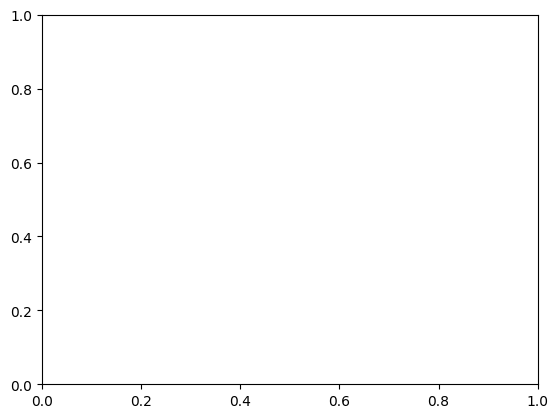

In [39]:
# visualize predictions
fig, ax = plt.subplots()

ax.plot(errors, 'b-', label='error')
ax.plot(pred_df[0], 'k--', label='actual')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized SWC_5 Error')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

In [40]:
# switch to another data set to check code
# check batch generation
# tensor flow tutorial (first part)